# 14.4.2 导数噪声与独立轨迹

## 学习目标与先修知识

比较真实导数（derivative）与含噪有限差分（finite difference），使用独立初值（initial condition）检验候选方程。

先修：14.4.1 稀疏回归；6.2 采样（sampling）与差分噪声；8.3 验证划分；4.6 Lorenz 基准。

## 具体问题

从观测（observation）序列求导后再拟合方程，噪声会怎样影响系数？一条训练轨迹（trajectory）上拟合好，是否说明新初值的预测可靠？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

对无噪声和轻微扰动的相邻观测做同一差分，观察短采样间隔下噪声差的放大。

In [2]:
times=np.linspace(0,3,31);growth=1.2;crowding=.4;initial=.25;exponential=np.exp(growth*times)
clean=growth*initial*exponential/(growth+crowding*initial*(exponential-1))
noise=np.random.default_rng(14).normal(0,.02,len(times));observed=clean+noise
print('状态噪声标准差',np.std(noise),'；导数差标准差',np.std(np.gradient(observed,times)-np.gradient(clean,times)))

状态噪声标准差 0.02404833271892092 ；导数差标准差 0.18571665361167472


## 模型假设

真值轨迹只用于生成与最后核验；拟合仅用含噪训练轨迹。噪声是固定种子、独立加性正态抽样，非生物观测的普遍模型（model）。阈值和字典事前固定；独立初值 $x_0=0.8$ 不用于拟合或调参。

## 数学解释与推导

中心差分（central difference） $\hat d_i=(y_{i+1}-y_{i-1})/(t_{i+1}-t_{i-1})$ 将观测噪声相减后除以时间间隔，因此缩短采样间隔并不自动改善含噪导数。令训练字典 $[1,y_i,y_i^2]$，估计的系数只是该导数估计和阈值规则下的候选。完整轨迹而非相邻点分开训练与留出，避免共享状态（state）产生泄漏。对混沌（chaos）系统，长期逐点误差还受初值敏感性（sensitivity to initial conditions）影响；此处只对非混沌增长例检查预测。

## 核心实现

以下是本节完整计算步骤，可逐行修改。

In [3]:
def finite_derivative(times, observations):
    clock = np.asarray(times, dtype=float)
    values = np.asarray(observations, dtype=float)
    rate = np.empty_like(values)
    rate[0] = (values[1]-values[0]) / (clock[1]-clock[0])
    rate[-1] = (values[-1]-values[-2]) / (clock[-1]-clock[-2])
    rate[1:-1] = (values[2:]-values[:-2]) / (clock[2:]-clock[:-2])
    return rate.tolist()


def logistic_exact(times, initial, growth, crowding):
    """Exact logistic trajectory for growth>0 and positive initial state."""
    clock = np.asarray(times, dtype=float)
    exponential = np.exp(growth * clock)
    return growth * initial * exponential / (growth + crowding * initial * (exponential-1))


def sparse_stlsq(theta, derivative, threshold, max_iter):
    """Column-normalized sequential thresholded least squares."""
    library = np.asarray(theta, dtype=float)
    target = np.asarray(derivative, dtype=float)
    scales = np.linalg.norm(library, axis=0)
    safe = np.where(scales > 0, scales, 1.)
    normalized = library / safe
    coefficient = np.linalg.lstsq(normalized, target, rcond=None)[0]
    support = np.abs(coefficient) >= threshold
    for _ in range(max_iter):
        if not np.any(support):
            coefficient[:] = 0
            break
        updated = np.zeros_like(coefficient)
        updated[support] = np.linalg.lstsq(normalized[:, support], target, rcond=None)[0]
        new_support = np.abs(updated) >= threshold
        coefficient = updated
        if np.array_equal(new_support, support):
            break
        support = new_support
    support = np.abs(coefficient) >= threshold
    coefficient[~support] = 0
    return [(coefficient / safe).tolist(), np.flatnonzero(support).tolist()]


def lorenz_rhs(state, sigma=10., rho=28., beta=8/3):
    x, y, z = np.asarray(state, dtype=float)
    return np.array([sigma*(y-x), x*(rho-z)-y, x*y-beta*z])


def lorenz_rk4(initial, dt, steps):
    state = np.asarray(initial, dtype=float)
    history = [state.copy()]
    for _ in range(steps):
        k1 = lorenz_rhs(state)
        k2 = lorenz_rhs(state + dt*k1/2)
        k3 = lorenz_rhs(state + dt*k2/2)
        k4 = lorenz_rhs(state + dt*k3)
        state = state + dt*(k1+2*k2+2*k3+k4)/6
        history.append(state.copy())
    return np.asarray(history)

## 对照实验

在固定阈值下由含噪训练轨迹估计导数，比较真值导数拟合，并用独立初值短时滚动。再重复噪声抽样描述变异。最后以第 4.6 章的 Lorenz 方程作干净导数基准，限定为课程核验。

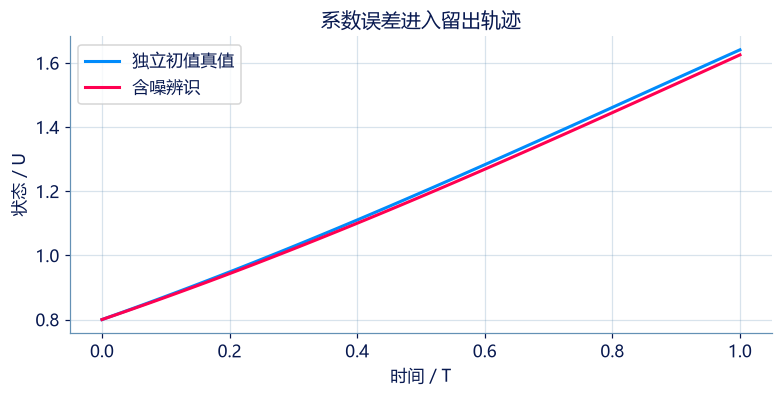

真导数系数 [ 0.   1.2 -0.4] ；一次含噪系数 [ 0.     1.137 -0.358]
20次系数范围 [-0.268  0.757 -0.593] [ 0.211  1.696 -0.215]
Lorenz 候选项 [1,x,y,z,xy,xz,yz,x²,y²,z²] 的系数：
[[  0.    -10.     10.      0.      0.      0.      0.      0.      0.
    0.   ]
 [  0.     28.     -1.      0.      0.     -1.      0.      0.      0.
    0.   ]
 [  0.      0.      0.     -2.667   1.      0.      0.      0.      0.
    0.   ]]


In [4]:
times=np.linspace(0,3,31);clean=logistic_exact(times,.25,1.2,.4)
truth_rate=1.2*clean-.4*clean*clean
clean_coef,_=sparse_stlsq(np.column_stack([np.ones_like(clean),clean,clean*clean]),truth_rate,.03,8)
def noisy_fit(seed):
    y=clean+np.random.default_rng(seed).normal(0,.02,len(clean))
    estimate=finite_derivative(times,y)
    return sparse_stlsq(np.column_stack([np.ones_like(y),y,y*y]),estimate,.03,8)[0]
fitted=np.asarray(noisy_fit(14));repeats=np.asarray([noisy_fit(seed) for seed in range(20)])
def predict(coefficients,initial,dt,steps):
    state=float(initial);result=[state]
    for _ in range(steps):
        state+=dt*(coefficients[0]+coefficients[1]*state+coefficients[2]*state*state)
        result.append(state)
    return np.asarray(result)
held_time=np.linspace(0,1,101);held_truth=logistic_exact(held_time,.8,1.2,.4)
held_fit=predict(fitted,.8,.01,100)
fig,ax=plt.subplots(figsize=(7,3.5));ax.plot(held_time,held_truth,label='独立初值真值',color=BLUE);ax.plot(held_time,held_fit,label='含噪辨识',color=PINK)
ax.set(xlabel='时间 / T',ylabel='状态 / U',title='系数误差进入留出轨迹');ax.legend();ax.grid(alpha=.25);plt.show()
print('真导数系数',np.round(clean_coef,3),'；一次含噪系数',np.round(fitted,3));print('20次系数范围',np.round(repeats.min(axis=0),3),np.round(repeats.max(axis=0),3))
# Lorenz 只作为已知生成方程与导数的课程基准；不把这段计算称作原论文复现。
lorenz=np.vstack([lorenz_rk4(initial,.01,300) for initial in ([1,1,1],[-5,4,20],[10,-8,15],[2,3,30])])
lx,ly,lz=lorenz.T
library=np.column_stack([np.ones(len(lorenz)),lx,ly,lz,lx*ly,lx*lz,ly*lz,lx*lx,ly*ly,lz*lz])
rates=np.asarray([lorenz_rhs(row) for row in lorenz])
lorenz_coefficients=np.asarray([sparse_stlsq(library,rates[:,i],.01,8)[0] for i in range(3)])
print('Lorenz 候选项 [1,x,y,z,xy,xz,yz,x²,y²,z²] 的系数：')
print(np.round(lorenz_coefficients,3))

## 结果解释

含噪导数带来的系数和支持变化在重复抽样间并不相同；一次成功的曲线贴合不足以宣称结构恢复。留出初值不能回用于选择阈值，否则本次报告的误差不再是独立检验。Lorenz 干净导数例能够恢复题定方程项，但没有覆盖含噪观测、原论文数据协议或混沌长时几何验证。

### 独立核对

核对解析导数拟合；检查差分误差明显高于状态噪声，并在新初值报告实际预测误差。

In [5]:
np.testing.assert_allclose(clean_coef,[0,1.2,-.4],atol=1e-10)
assert np.std(np.asarray(finite_derivative(times,observed))-np.asarray(finite_derivative(times,clean)))>np.std(noise)
assert np.isfinite(held_fit).all()
known=np.zeros((3,10));known[0,[1,2]]=[-10,10];known[1,[1,2,5]]=[28,-1,-1];known[2,[3,4]]=[-8/3,1]
np.testing.assert_allclose(lorenz_coefficients,known,atol=1e-8)
print('留出终点绝对误差：',abs(held_fit[-1]-held_truth[-1]))

留出终点绝对误差： 0.0157603531949424


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/explore/)，再返回此处核对完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：从不等距采样估计变化率

返回每个时刻的有限差分（finite difference）导数（derivative）：内部点用前后两点，首末点用相邻两点。

**函数与代码模板**

```python
def solve(
    times: list[float],
    observations: list[float],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 严格递增的采样（sampling）时刻。 | T |
| `observations` | `list[float]` | 对应状态（state）观测（observation）。 | U |

**返回值**

直接返回 rates（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | 按原顺序的导数估计。 | U/T |

**计算规则**

内部 i 用 (y_(i+1)−y_(i−1))/(t_(i+1)−t_(i−1))；端点分别用相邻两点。等距和不等距均按同一公式，不能把估计当作无噪声真导数。

**约束与边界**

- 时刻长度≥2且严格递增，观测等长；全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 严格递增的采样（sampling）时刻。 | [0.0, 1.0, 2.0] | T |
| observations | 对应状态（state）观测（observation）。 | [0.0, 2.0, 4.0] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0.0, 1.0, 2.0]
observations = [0.0, 2.0, 4.0]

result = solve(times, observations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rates | 按原顺序的导数估计。 | [2.0, 2.0, 2.0] | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.0, 2.0, 2.0]
```

**样例解释**

首例三处差分均为 2 U/T；内部差分只读两侧观测。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：从不等距采样估计变化率](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/practice/?question=p14-finite-derivative)

### 第 2 题 · 单项选择题：缩短采样一定更好吗

有固定幅度的独立观测（observation）噪声时，直接差分并缩小时间间隔，可能出现什么？

- **A.** 噪声差除以更小间隔，导数（derivative）误差可变大。
- **B.** 导数误差必严格变小。
- **C.** 原状态（state）观测自动无噪声。
- **D.** 差分所得一定是机制真导数。

[作答：缩短采样一定更好吗](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/practice/?question=p14-noise-difference)

### 第 3 题 · 单项选择题：何为独立轨迹验证

要检验辨识方程对新初值（initial condition）的预测，应怎样分割？

- **A.** 训练与留出使用不同的完整轨迹（trajectory），留出不用于阈值选择。
- **B.** 随机打散同一轨迹的相邻点当作独立轨迹。
- **C.** 在留出结果最好时选阈值，仍报告它为独立测试。
- **D.** 只报告训练导数（derivative）拟合。

[作答：何为独立轨迹验证](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/practice/?question=p14-trajectory-split)

### 第 4 题 · 单项选择题：混沌基准的比较

在 Lorenz 类混沌（chaos）基准上，两个模型（model）长时逐点轨迹（trajectory）分离，哪项结论最谨慎？

- **A.** 还需看方程、短时预测和限定窗口的长期几何，不能只凭逐点分离判错。
- **B.** 逐点分离证明某模型从未拟合数据。
- **C.** 不需要固定初值（initial condition）与容差。
- **D.** 漂亮吸引子（attractor）图形足以证明原论文复现。

[作答：混沌基准的比较](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/practice/?question=p14-chaotic-long-term)

**进一步阅读**

[SINDy 原论文](https://doi.org/10.1073/pnas.1517384113)用于方法背景；含噪导数与留出例是本课程单独构造。